In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [25]:
# Download dataset
path = kagglehub.dataset_download("vikrishnan/boston-house-prices")

print("Dataset Path:", path)

Dataset Path: C:\Users\madha\.cache\kagglehub\datasets\vikrishnan\boston-house-prices\versions\1


In [26]:
import os

file_path = os.path.join(path, "housing.csv")
df = pd.read_csv(file_path, sep="\s+", header=None)
df.columns = [
'CRIM','ZN','INDUS','CHAS','NOX','RM','AGE',
'DIS','RAD','TAX','PTRATIO','B','LSTAT','MEDV'
]

df.head()

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
C:\Users\madha\AppData\Local\Temp\ipykernel_21968\928981956.py:4: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(file_path, sep="\s+", header=None)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [27]:
df.shape
df.columns
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [33]:
X = df.drop('MEDV', axis=1).values
y = df['MEDV'].values

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [35]:
from sklearn.model_selection import train_test_split

# Train + temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42)

# Validation + Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (354, 13)
Validation: (76, 13)
Test: (76, 13)


In [31]:
import numpy as np
def gaussian_kernel(x, xi, tau):
    diff = x - xi
    return np.exp(-(np.dot(diff, diff)) / (2 * tau**2))

In [32]:
def locally_weighted_regression(X_train, y_train, X_query, tau=0.5, reg_lambda=1e-2):

    m = X_train.shape[0]
    n = X_train.shape[1]
    X_train_aug = np.hstack((np.ones((m, 1)), X_train))

    predictions = []
    I = np.eye(n + 1)
    I[0, 0] = 0  # Do not regularize intercept

    for x in X_query:

        weights = np.array([
            gaussian_kernel(x, xi, tau) for xi in X_train
        ])

        W = np.diag(weights.flatten())

        theta = np.linalg.pinv(
            X_train_aug.T @ W @ X_train_aug + reg_lambda * I
        ) @ X_train_aug.T @ W @ y_train

        x_aug = np.concatenate(([1], x))

        y_pred = x_aug @ theta
        predictions.append(y_pred)

    return np.array(predictions)

In [36]:
tau_candidates = [0.3, 0.5, 0.8, 1.2, 1.8]
lambda_candidates = [1e-4, 1e-3, 1e-2, 1e-1]

best_tau = None
best_lambda = None
best_mse = float("inf")

for tau in tau_candidates:
    for reg_lambda in lambda_candidates:
        y_val_pred_try = locally_weighted_regression(
            X_train, y_train, X_val, tau=tau, reg_lambda=reg_lambda
        )
        mse_try = mean_squared_error(y_val, y_val_pred_try)

        if mse_try < best_mse:
            best_mse = mse_try
            best_tau = tau
            best_lambda = reg_lambda

tau = best_tau
reg_lambda = best_lambda

y_val_pred = locally_weighted_regression(
    X_train, y_train, X_val, tau=tau, reg_lambda=reg_lambda
)

print("Best tau:", tau)
print("Best reg_lambda:", reg_lambda)

Best tau: 0.8
Best reg_lambda: 0.1


In [17]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_val, y_val_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_val, y_val_pred)

print("Validation MSE:", mse)
print("Validation RMSE:", rmse)
print("Validation R2 Score:", r2)

Validation MSE: 5.076767477675325
Validation RMSE: 2.253168319872114
Validation R2 Score: 0.9268160659516922


In [18]:
y_test_pred = locally_weighted_regression(
    X_train, y_train, X_test, tau=tau, reg_lambda=reg_lambda
)

mse_test = mean_squared_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

print("Test MSE:", mse_test)
print("Test R2:", r2_test)

Test MSE: 17.509638516844213
Test R2: 0.7796957866523737


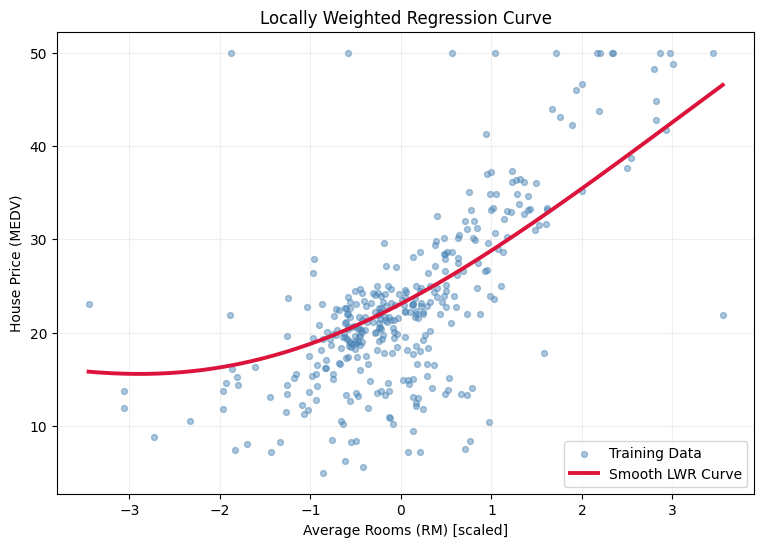

Raw input features: {'CRIM': 0.00632, 'ZN': 18.0, 'INDUS': 2.31, 'CHAS': 0, 'NOX': 0.538, 'RM': 6.575, 'AGE': 65.2, 'DIS': 4.09, 'RAD': 1, 'TAX': 296.0, 'PTRATIO': 15.3, 'B': 396.9, 'LSTAT': 4.98}

Predicted House Price (MEDV): $27.00k


In [39]:
import matplotlib.pyplot as plt

# Make this cell safe to run independently by resolving required variables from notebook state
required_vars = ["X_train", "y_train", "scaler", "tau", "reg_lambda", "locally_weighted_regression"]
missing = [name for name in required_vars if name not in globals()]
if missing:
    raise RuntimeError(
        "Run all previous training/evaluation cells first. Missing: " + ", ".join(missing)
    )

X_train_local = globals()["X_train"]
y_train_local = globals()["y_train"]
scaler_local = globals()["scaler"]
tau_local = globals()["tau"]
reg_lambda_local = globals()["reg_lambda"]

plt.figure(figsize=(9, 6))
plt.scatter(X_train_local[:, 5], y_train_local, color="steelblue", alpha=0.45, s=18, label="Training Data")

# Build a smooth 1D curve: vary only RM on a dense grid, keep other features at training medians
x_template = np.median(X_train_local, axis=0)
rm_min, rm_max = X_train_local[:, 5].min(), X_train_local[:, 5].max()
rm_grid = np.linspace(rm_min, rm_max, 220)
X_curve = np.tile(x_template, (len(rm_grid), 1))
X_curve[:, 5] = rm_grid

# Use larger tau and stronger regularization to get a smoother, less wiggly fit
smooth_tau = max(float(tau_local), 1.8)
smooth_lambda = max(float(reg_lambda_local), 0.1)
y_curve = locally_weighted_regression(
    X_train_local, y_train_local, X_curve, tau=smooth_tau, reg_lambda=smooth_lambda
)

plt.plot(rm_grid, y_curve, color="crimson", linewidth=2.8, label="Smooth LWR Curve")
plt.xlabel("Average Rooms (RM) [scaled]")
plt.ylabel("House Price (MEDV)")
plt.title("Locally Weighted Regression Curve")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

# Predict for a new house using raw (unscaled) feature values
raw_input = {
    "CRIM": 0.00632,
    "ZN": 18.0,
    "INDUS": 2.31,
    "CHAS": 0,
    "NOX": 0.538,
    "RM": 6.575,
    "AGE": 65.2,
    "DIS": 4.09,
    "RAD": 1,
    "TAX": 296.0,
    "PTRATIO": 15.3,
    "B": 396.9,
    "LSTAT": 4.98,
}

feature_order = [
    "CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE",
    "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT"
]

raw_array = np.array([[raw_input[f] for f in feature_order]])
scaled_input = scaler_local.transform(raw_array)

predicted_price = locally_weighted_regression(
    X_train_local, y_train_local, scaled_input, tau=tau_local, reg_lambda=reg_lambda_local
)[0]

print("Raw input features:", raw_input)
print(f"\nPredicted House Price (MEDV): ${predicted_price:.2f}k")